# Reasoning about Joint Probability Distributions

This tutorial walks through the inference capabilities of
`jpt.trees.JPT`.
We cover every supported query type:

| Query | Method | Returns |
|---|---|---|
| Marginal $P(\mathcal{E}=e)$ | `infer` | `float` |
| Conditional $P(Q \mid E)$ | `infer` | `float` |
| Posterior distributions $P(Q \mid E)$ | `posterior` | `VariableMap` of distributions |
| Expected values $\mathbb{E}[Q \mid E]$ | `expectation` | `VariableMap` of scalars |
| Most probable explanation (MPE) | `mpe` | assignment + likelihood |
| $k$ most probable explanations | `kmpe` | iterator of assignments |

We first train a model on the Iris dataset (the same setup as in
[tutorial_learning](tutorial_learning.ipynb)).

In [1]:
import sklearn.datasets
import pandas as pd
from jpt.variables import infer_from_dataframe
from jpt.trees import JPT

dataset = sklearn.datasets.load_iris()
df = pd.DataFrame(columns=dataset.feature_names, data=dataset.data)

target = dataset.target.astype(object)
for idx, name in enumerate(dataset.target_names):
    target[target == idx] = name

df['plant'] = target

variables = infer_from_dataframe(df)
varnames = {v.name: v for v in variables}

model = JPT(variables, min_samples_leaf=0.1)
model.fit(df)
model

<JPT #innernodes = 6, #leaves = 7 (13 total)>

## Marginal Queries

A **marginal query** computes the probability of a partial state
$P(\mathcal{E} = e)$ by integrating out all unassigned variables.  In
``pyjpt`` this is expressed as a call to
`infer` with a `query`
but no `evidence`.

The query is a plain Python `dict` mapping variable names (or variable
objects) to values or ranges.  Ranges for numeric variables are given as
two-element lists `[lower, upper]`.

In [2]:
# P(plant = 'setosa')
p_setosa = model.infer(query={'plant': 'setosa'})
print(f'P(plant=setosa) = {p_setosa:.4f}')

# P(sepal length in [5, 6])
p_sepal = model.infer(query={'sepal length (cm)': [5., 6.]})
print(f'P(sepal length in [5,6]) = {p_sepal:.4f}')

# Joint marginal: P(plant in {setosa, versicolor} AND sepal length in [5, 6])
p_joint = model.infer(
    query={
        'plant': {'setosa', 'versicolor'},
        'sepal length (cm)': [5., 6.]
    }
)
print(f'P(plant in {{setosa,versicolor}}, sepal in [5,6]) = {p_joint:.4f}')

P(plant=setosa) = 0.3333
P(sepal length in [5,6]) = 0.3861
P(plant in {setosa,versicolor}, sepal in [5,6]) = 0.3310


## Conditional Queries

A **conditional query** computes $P(Q \mid E) = P(Q, E) / P(E)$.  The
`query` argument specifies $Q$ and the `evidence` argument specifies $E$.
The method returns a scalar probability.

In [3]:
# P(plant = 'virginica' | sepal length in [6, 7])
p_cond = model.infer(
    query={'plant': 'virginica'},
    evidence={'sepal length (cm)': [6., 7.]}
)
print(f'P(plant=virginica | sepal in [6,7]) = {p_cond:.4f}')

# P(petal length > 4 | plant = 'versicolor')
p_petal = model.infer(
    query={'petal length (cm)': [4., float('inf')]},
    evidence={'plant': 'versicolor'}
)
print(f'P(petal length > 4 | plant=versicolor) = {p_petal:.4f}')

P(plant=virginica | sepal in [6,7]) = 0.5918
P(petal length > 4 | plant=versicolor) = 0.6864


When the evidence has zero probability (unsatisfiable), `infer` raises an
exception by default.  Pass `fail_on_unsatisfiability=False` to get `None`
instead:

In [4]:
result = model.infer(
    query={'plant': 'setosa'},
    evidence={'plant': 'virginica'},
    fail_on_unsatisfiability=False
)
print('Result for contradictory evidence:', result)

Result for contradictory evidence: 0.0


## Posterior Distributions

While `infer` collapses the answer to a single number,
`posterior` returns
the full posterior distribution over each query variable given the evidence.
The result is a
`VariableMap`
mapping each variable to its posterior distribution object.

For **numeric variables** the posterior is a
`Numeric` distribution; its `pdf`
and `cdf` attributes are callable functions over the real line.

For **symbolic variables** the posterior is a
`Multinomial` distribution; its
`probabilities` array is indexed in the same order as `variable.domain`.

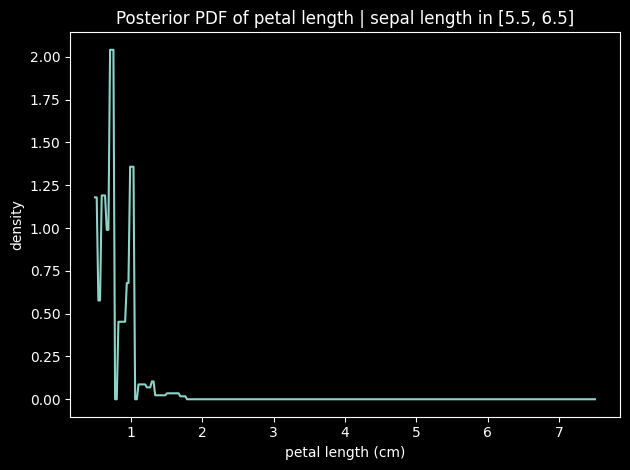

TypeError: 'type' object is not iterable

In [5]:
import numpy as np
import matplotlib.pyplot as plt

post = model.posterior(
    variables=[varnames['petal length (cm)'], varnames['plant']],
    evidence={'sepal length (cm)': [5.5, 6.5]}
)

# --- Numeric posterior: plot the PDF ---
petal_dist = post[varnames['petal length (cm)']]
x = np.linspace(0.5, 7.5, 300)
y = [petal_dist.pdf(xi) for xi in x]

plt.figure()
plt.plot(x, y)
plt.xlabel('petal length (cm)')
plt.ylabel('density')
plt.title('Posterior PDF of petal length | sepal length in [5.5, 6.5]')
plt.tight_layout()
plt.show()

# --- Symbolic posterior: bar chart ---
plant_dist = post[varnames['plant']]
labels = list(varnames['plant'].domain)
probs = [plant_dist.p(label) for label in labels]

plt.figure()
plt.bar(labels, probs)
plt.ylabel('probability')
plt.title('Posterior P(plant | sepal length in [5.5, 6.5])')
plt.tight_layout()
plt.show()

Note that the posterior variables are returned **independently**: the
`VariableMap` does not encode the joint distribution over the query
variables, only the marginal of each.  If you need the full conditional joint
distribution, use
`conditional_jpt`.

## Expectations

`expectation`
computes $\mathbb{E}[Q_i \mid E]$ for each variable in a query set and
returns a `VariableMap` of scalar values.

For symbolic variables the expectation is not defined; those variables are
silently skipped.

In [6]:
numeric_vars = [
    varnames['sepal width (cm)'],
    varnames['petal length (cm)'],
    varnames['petal width (cm)']
]

exp = model.expectation(
    variables=numeric_vars,
    evidence={'plant': 'versicolor'}
)

for var, value in exp.items():
    print(f'E[{var.name} | plant=versicolor] = {value:.4f}')

E[sepal width (cm) | plant=versicolor] = 2.7411
E[petal length (cm) | plant=versicolor] = 4.1313
E[petal width (cm) | plant=versicolor] = nan


## Most Probable Explanation (MPE)

The **most probable explanation** query answers
$\operatorname{argmax}_{Q} P(Q \mid E)$: given evidence $E$, find the
assignment of unobserved variables that jointly maximises the probability.

`mpe` returns a tuple of
`(assignments, likelihood)`.  `assignments` is a list of
`LabelAssignment`
objects — multiple assignments may be returned when several leaves tie for
the maximum.  The `likelihood` is the joint probability density/mass of the
best assignment.

In [7]:
assignments, likelihood = model.mpe(
    evidence={'plant': 'virginica'}
)

print(f'Likelihood of best explanation: {likelihood:.6f}')
for i, assignment in enumerate(assignments):
    print(f'  Assignment {i}: {assignment}')

Likelihood of best explanation: 7.072741
  Assignment 0: <LabelAssignment {sepal length (cm): <ContinuousSet=[6.200,6.400)>, sepal width (cm): <ContinuousSet=[3.000,3.100)>, petal length (cm): <ContinuousSet=[5.500,5.600)>, petal width (cm): <ContinuousSet=[2.200,2.300)>, plant: {np.str_('virginica')}}>


## k Most Probable Explanations (k-MPE)

`kmpe` generalises MPE
to return an iterator that yields the $k$ best explanations in descending
order of likelihood.  This is useful when the single best assignment is not
sufficient, e.g. to present a ranked list of hypotheses.

Set `k=0` to retrieve all explanations (bounded by the number of leaves).

In [8]:
k = 3

print(f'Top-{k} explanations given plant=versicolor:\n')
for rank, (assignment, likelihood) in enumerate(
        model.kmpe(evidence={'plant': 'versicolor'}, k=k),
        start=1
):
    print(f'  Rank {rank}  (likelihood={likelihood:.6f})')
    print(f'    {assignment}\n')

Top-3 explanations given plant=versicolor:

  Rank 1  (likelihood=4.204493)
    <LabelAssignment {plant: {np.str_('versicolor')}, petal width (cm): <ContinuousSet=[1.400,1.500)>, petal length (cm): <ContinuousSet=[4.300,4.500)>, sepal width (cm): <ContinuousSet=[2.800,2.900)>, sepal length (cm): <ContinuousSet=[6.000,6.100)>}>

  Rank 2  (likelihood=3.822266)
    <LabelAssignment {plant: {np.str_('versicolor')}, petal width (cm): <ContinuousSet=[1.400,1.500)>, petal length (cm): <ContinuousSet=[4.600,4.700)>, sepal width (cm): <ContinuousSet=[2.800,2.900)>, sepal length (cm): <ContinuousSet=[6.000,6.100)>}>

  Rank 3  (likelihood=3.503744)
    <LabelAssignment {plant: {np.str_('versicolor')}, petal width (cm): <ContinuousSet=[1.400,1.500)>, petal length (cm): <ContinuousSet=[4.300,4.500)>, sepal width (cm): <ContinuousSet=[2.800,2.900)>, sepal length (cm): <ContinuousSet=[6.100,6.300)>}>



## Using `bind` to Construct Queries

All inference methods accept raw Python `dict` objects, but
`bind` can be used to
construct a validated
`LabelAssignment`
explicitly.  This is useful for reusing and inspecting queries, or when
building queries programmatically.

See `important_datastructures` for a full
treatment of `LabelAssignment` and the underlying set types.

In [ ]:
query = model.bind({
    'plant': {'setosa', 'versicolor'},
    'sepal length (cm)': [5., 6.]
})
evidence = model.bind({'petal width (cm)': [0., 1.]})

print('Query:   ', query)
print('Evidence:', evidence)

p = model.infer(query=query, evidence=evidence)
print(f'\nP(query | evidence) = {p:.4f}')